In [2]:
import pandas as pd
import os
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import torch
import polars as pl
import umap
import glob
import umap
import re

In [4]:
# load combined env data
# env_filepath = '../data/envcombined_env_si_airtemp_01.parquet'
env_filepath = '../data/combined_env_data.parquet'
env_path = os.path.join(env_filepath)
df_env = pd.read_parquet(env_path)

In [5]:
df_env.head()

,Timestamp,Tair_C,Si,Lat,Lon,Alt_m,Campaign,source_file,Tair_K,Pressure_hPa
0,2000-03-09 18:31:10+00:00,9.001,-0.484336,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
1,2000-03-09 18:31:10.250000+00:00,9.012,-0.484815,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
2,2000-03-09 18:31:10.500000+00:00,9.033,-0.485818,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
3,2000-03-09 18:31:10.750000+00:00,9.059,-0.486805,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
4,2000-03-09 18:31:11+00:00,9.078,-0.487472,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN


In [6]:
df_env.columns

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file', 'Tair_K', 'Pressure_hPa'],
      dtype='str')

In [7]:
# Check variables available for each campaign
campaigns = df_env['Campaign'].unique()
summary = {}

for camp in campaigns:
    df_camp = df_env[df_env['Campaign'] == camp]
    valid_counts = df_camp.notna().sum()
    summary[camp] = valid_counts

# Convert to DataFrame for easier viewing
summary_df = pd.DataFrame(summary).T
print(summary_df)

                   Timestamp  Tair_C      Si     Lat     Lon   Alt_m  \
ARM                   429040  429040  429040  429040  429040  429040   
CRYSTAL-FACE-NASA     148610  148610  148610       0       0       0   
CRYSTAL-FACE-UND      185420  182976  132956       0       0       0   
MC3E                  165431  163154  145875  150024  150024  165431   
MIDCIX                 75927   75927   75927       0       0       0   
OLYMPEX               209321  209321  122678  209321  209321  209321   
AIRS-II               312792  312792  312792  312792  312792  312792   
ATTREX                581370  579628  468919  581370  581370  581370   
IPHEX                 287600  286538  192929  285923  285923  285923   
ISDAC                 357071  356773  357071  357071  348190  357061   
POSIDON               190418  186485  182767  133966  133966  133966   
ESCAPE                 67380   67380   67148   67380   67380    3996   
ICE-L                 210561  210525  209137  210530  210530  20

In [8]:
df_env.dtypes

Timestamp       datetime64[ns, UTC]
Tair_C                      float64
Si                          float64
Lat                         float64
Lon                         float64
Alt_m                       float64
Campaign                        str
source_file                     str
Tair_K                      float64
Pressure_hPa                float64
dtype: object

In [9]:
env_campaigns = df_env['Campaign'].unique()
env_campaigns

<ArrowStringArray>
[              'ARM', 'CRYSTAL-FACE-NASA',  'CRYSTAL-FACE-UND',
              'MC3E',            'MIDCIX',           'OLYMPEX',
           'AIRS-II',            'ATTREX',             'IPHEX',
             'ISDAC',           'POSIDON',            'ESCAPE',
             'ICE-L',            'MACPEX']
Length: 14, dtype: str

In [10]:
# TEMP: replace dash with underscore in env df
# TODO: in parsers, change the "-" to "_" for campaign names
df_env["Campaign"] = df_env["Campaign"].str.replace("-", "_")

In [11]:
# check that it was changed correctly
df_env['Campaign'].unique()

<ArrowStringArray>
[              'ARM', 'CRYSTAL_FACE_NASA',  'CRYSTAL_FACE_UND',
              'MC3E',            'MIDCIX',           'OLYMPEX',
           'AIRS_II',            'ATTREX',             'IPHEX',
             'ISDAC',           'POSIDON',            'ESCAPE',
             'ICE_L',            'MACPEX']
Length: 14, dtype: str

In [13]:
# filepath: /home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet
parquet_path = "/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet"

df = pl.read_parquet(parquet_path)
unique_campaigns = df["campaign"].unique()
print("Unique campaigns:", unique_campaigns.to_list())

Unique campaigns: ['MACPEX', 'ATTREX', 'IPHEX', 'MIDCIX', 'ARM', 'CRYSTAL_FACE_UND', 'ISDAC', 'MPACE', 'CRYSTAL_FACE_NASA', 'MC3E', 'AIRS_II', 'ICE_L']


In [12]:
# load cpi3m embeddings (from SSL Model v3)
cpi3m_path = "/home/jko/ssl-cpi-analysis/data/SSL-Model-v3/cpi3m_campaign_cls_head_features_compressed.parquet"
scan = pl.scan_parquet(cpi3m_path)

# campaigns = [
#     "CRYSTAL_FACE_NASA",
#     "ARM",
#     "CRYSTAL_FACE_UND",
#     "MIDCIX",
#     "MC3E",
#     "ATTREX"
# ]
campaigns = df_env['Campaign'].unique()

cpi3m_selected = (
    scan
    .filter(pl.col("campaign").is_in(campaigns))
    .collect()
)

print(type(cpi3m_selected))
print(cpi3m_selected.head())


<class 'polars.dataframe.frame.DataFrame'>
shape: (5, 5)
┌─────────────────────┬─────────────────────┬──────────┬─────────────────────┬─────────────────────┐
│ campaign_file_id    ┆ cls_features        ┆ campaign ┆ filename            ┆ head_features       │
│ ---                 ┆ ---                 ┆ ---      ┆ ---                 ┆ ---                 │
│ str                 ┆ list[f32]           ┆ str      ┆ str                 ┆ list[f32]           │
╞═════════════════════╪═════════════════════╪══════════╪═════════════════════╪═════════════════════╡
│ AIRS_II/1114-115708 ┆ [-1.573681,         ┆ AIRS_II  ┆ 1114-115708_753_18. ┆ [-0.174372,         │
│ _753_18.png         ┆ -1.34678, … 1.0547… ┆          ┆ png                 ┆ 0.220068, … 0.1956… │
│ AIRS_II/1114-115708 ┆ [-0.664088,         ┆ AIRS_II  ┆ 1114-115708_753_25. ┆ [0.150885,          │
│ _753_25.png         ┆ -0.620979, … 1.610… ┆          ┆ png                 ┆ 0.086997, …         │
│                     ┆           

In [15]:
# number of samples per campaign
counts = (
    cpi3m_selected
    .with_columns(pl.col("campaign").str.replace_all("-", "_"))
    .group_by("campaign")
    .len()
    .sort("campaign")
)

print(counts)
print(counts.shape)

shape: (11, 2)
┌───────────────────┬─────────┐
│ campaign          ┆ len     │
│ ---               ┆ ---     │
│ str               ┆ u32     │
╞═══════════════════╪═════════╡
│ AIRS_II           ┆ 92201   │
│ ARM               ┆ 295703  │
│ ATTREX            ┆ 129128  │
│ CRYSTAL_FACE_NASA ┆ 78152   │
│ CRYSTAL_FACE_UND  ┆ 1617826 │
│ …                 ┆ …       │
│ IPHEX             ┆ 40692   │
│ ISDAC             ┆ 505812  │
│ MACPEX            ┆ 80240   │
│ MC3E              ┆ 187558  │
│ MIDCIX            ┆ 90761   │
└───────────────────┴─────────┘
(11, 2)


In [17]:
# Print the date range of campaign
campaign = 'ATTREX'
df = cpi3m_selected.filter(cpi3m_selected['campaign']==campaign)

# Extract datetime from the filename
df = df.with_columns(
    pl.col("filename")
    .str.extract(r"(\d{4}_\d{4}_\d{6})")  # Extract the datetime part
    .str.strptime(pl.Datetime, format="%Y_%m%d_%H%M%S")  # Corrected: use 'format' instead of 'fmt'
    .alias("datetime")  # Add as a new column
)

# Calculate the date range
start_date = df["datetime"].min()
end_date = df["datetime"].max()

print(f"Date range: {start_date} to {end_date}")

Date range: 2014-03-04 17:41:32 to 2014-03-05 06:09:23


In [16]:
# Lazy scan
lf = pl.scan_parquet(cpi3m_path)

# Get unique campaign values
campaigns = (
    lf.select("campaign")
      .unique()
      .collect()
)

print(campaigns['campaign'].to_list())

['MPACE', 'ATTREX', 'MACPEX', 'ARM', 'MC3E', 'ICE_L', 'ISDAC', 'IPHEX', 'MIDCIX', 'CRYSTAL_FACE_NASA', 'AIRS_II', 'CRYSTAL_FACE_UND']


In [18]:
lf = pl.scan_parquet(cpi3m_path)

result = (
    lf.select(["campaign", "filename"])
      .group_by("campaign")
      .agg(
          pl.col("filename").head(5).alias("filenames")
      )
      .collect()
)

for row in result.iter_rows(named=True):
    print(f"\nCampaign: {row['campaign']}")
    for f in row["filenames"]:
        print(f"  {f}")


Campaign: CRYSTAL_FACE_NASA
  2002_0709_153238_705_260.png
  2002_0709_153238_705_268.png
  2002_0709_153345_757_14.png
  2002_0709_153345_757_15.png
  2002_0709_153345_757_18.png

Campaign: ARM
  2000_0306_202027_531_20.png
  2000_0306_202027_531_27.png
  2000_0306_202235_289_16.png
  2000_0306_202235_289_19.png
  2000_0306_202235_289_25.png

Campaign: ICE_L
  2007_1116_175640_725_125.png
  2007_1116_175640_725_139.png
  2007_1116_175640_725_54.png
  2007_1116_175646_141_104.png
  2007_1116_175646_141_31.png

Campaign: ATTREX
  2014_0304_174132_0.png
  2014_0304_174132_1.png
  2014_0304_174132_10.png
  2014_0304_174132_11.png
  2014_0304_174132_12.png

Campaign: MACPEX
  2011_0403_171110_0.png
  2011_0403_171110_1.png
  2011_0403_171110_10.png
  2011_0403_171110_100.png
  2011_0403_171110_101.png

Campaign: MIDCIX
  2004_0419_170329_342_1.png
  2004_0419_170329_342_14.png
  2004_0419_170329_342_16.png
  2004_0419_170329_342_179.png
  2004_0419_170329_342_19.png

Campaign: AIRS_II
  1

In [19]:
# sample random subset of each campaign
n_per_campaign = 20_000

cpi3m_sampled = (
    cpi3m_selected
    .group_by("campaign")
    .agg(
        pl.all().sample(n=n_per_campaign, with_replacement=False)
    )
    .explode(pl.all().exclude("campaign"))
)

print(cpi3m_sampled.shape)

(220000, 5)


In [20]:
# UMAP to reduce embeddings to 3-D 
X = cpi3m_sampled['cls_features'].to_list()
X = np.array(X, dtype=np.float32)
print("Embedding matrix:", X.shape)
# Run UMAP → 3 dimensions
umap_model = umap.UMAP(
    n_components=3,
    n_neighbors=100,
    min_dist=0.1,
    metric="cosine",
    n_jobs=-1
    # random_state=42,
)

X_umap = umap_model.fit_transform(X)
print("UMAP shape:", X_umap.shape)

Embedding matrix: (220000, 384)
UMAP shape: (220000, 3)


In [21]:
# Save UMAP embeddings
save_dir = '../data/umap'
save_filename = 'umap_d3_n220k_11campaigns.csv'
save_filepath = os.path.join(save_dir, save_filename)
np.savetxt(
    save_filepath,
    X_umap,
    delimiter=","
)

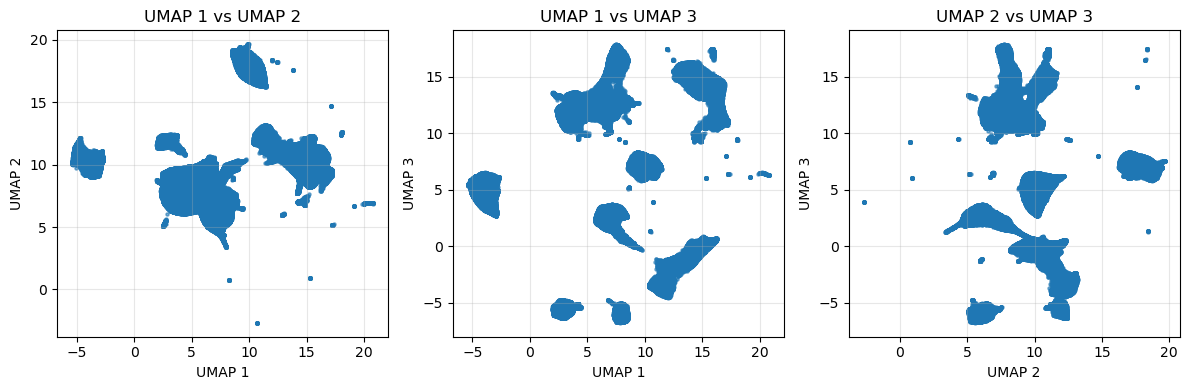

In [22]:
# plot UMAP in 3D
# Convert to named columns for clarity
umap1 = X_umap[:, 0]
umap2 = X_umap[:, 1]
umap3 = X_umap[:, 2]

# Create figure with 3 subplots
plt.figure(figsize=(12, 4))

# ---- Plot 1: UMAP1 vs UMAP2 ----
plt.subplot(1, 3, 1)
plt.scatter(umap1, umap2, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP 1 vs UMAP 2")
plt.grid(alpha=0.3)

# ---- Plot 2: UMAP1 vs UMAP3 ----
plt.subplot(1, 3, 2)
plt.scatter(umap1, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 3")
plt.title("UMAP 1 vs UMAP 3")
plt.grid(alpha=0.3)

# ---- Plot 3: UMAP2 vs UMAP3 ----
plt.subplot(1, 3, 3)
plt.scatter(umap2, umap3, s=5, alpha=0.6)
plt.xlabel("UMAP 2")
plt.ylabel("UMAP 3")
plt.title("UMAP 2 vs UMAP 3")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# normalize UMAP embeddings to RGB
# Assume X_umap is (N, 3)
umap_norm = (X_umap - X_umap.min(axis=0)) / (X_umap.max(axis=0) - X_umap.min(axis=0))
umap_norm = np.clip(umap_norm, 0, 1)       # safety

# Convert to 0–255 uint8 RGB
rgb = (umap_norm * 255).astype(np.uint8)

print(rgb.shape)   # (N, 3)

(220000, 3)


In [24]:
# Check CPI image filename formatting 
for campaign in cpi3m_sampled.select("campaign").unique().to_series():
    print(f"Campaign: {campaign}")
    samples = (
        cpi3m_sampled
        .filter(pl.col("campaign") == campaign)
        .select("filename")
        .head(5)
        .to_series()
        .to_list()
    )
    for fname in samples:
        print(f"  {fname}")
    print()

Campaign: AIRS_II
  2003_1119_174015_581_28.png
  1114-163126_523_89.png
  2003_1119_192242_409_4.png
  1114-154025_889_15.png
  1119-191432_19_34.png

Campaign: ISDAC
  2008_0402_023531_607_26.png
  2008_0428_225153_213_33.png
  2008_0429_025621_294_178.png
  2008_0427_024930_953_185.png
  2008_0408_232353_21_11.png

Campaign: ICE_L
  2007_1211_194404_126_20.png
  2007_1116_190702_154_7.png
  2007_1211_192852_508_44.png
  2007_1116_192046_577_15.png
  2007_1213_200209_657_20.png

Campaign: ATTREX
  2014_0305_040316_141.png
  2014_0304_230639_67.png
  2014_0305_055107_25.png
  2014_0304_180945_46.png
  2014_0304_204104_53.png

Campaign: CRYSTAL_FACE_UND
  2002_0707_192456_647_27.png
  2002_0726_222352_829_22.png
  2002_0718_183615_461_10.png
  2002_0729_202634_914_38.png
  2002_0726_222428_878_44.png

Campaign: MIDCIX
  2004_0427_195233_628_57.png
  2004_0422_165051_539_37.png
  2004_0502_181618_698_13.png
  2004_0427_165440_20_9.png
  2004_0427_200938_65_9.png

Campaign: MC3E
  2011_0

In [25]:
# Correct issues with filename formatting for AIRS-II campaign 
# the year is missing in front for some filenames 
def fix_airsii_filename(filename):
    if re.match(r"^\d{4}_", filename):
        return filename
    m = re.match(r"(\d{4})-(\d{6})", filename)
    if m:
        flight, yymmdd = m.groups()
        return f"2003_{yymmdd}_{flight}" + filename[m.end():]
    return filename

cpi3m_sampled = cpi3m_sampled.with_columns(
    pl.when(pl.col("campaign") == "AIRS_II")
      .then(pl.col("filename").map_elements(fix_airsii_filename, return_dtype=pl.String))
      .otherwise(pl.col("filename"))
      .alias("filename_fixed")
)

In [26]:
# Now use "filename_fixed" for your timestamp parsing
cpi3m_sampled = cpi3m_sampled.with_columns(
    pl.col("filename_fixed")
      .str.split("_")
      .list.slice(0, 3)
      .list.join("_")
      .str.strptime(pl.Datetime, format="%Y_%m%d_%H%M%S", strict=False)
      .alias("timestamp")
)

print(cpi3m_sampled.select(["filename", "timestamp"]).head())

shape: (5, 2)
┌─────────────────────────────┬─────────────────────┐
│ filename                    ┆ timestamp           │
│ ---                         ┆ ---                 │
│ str                         ┆ datetime[μs]        │
╞═════════════════════════════╪═════════════════════╡
│ 2002_0707_192456_647_27.png ┆ 2002-07-07 19:24:56 │
│ 2002_0726_222352_829_22.png ┆ 2002-07-26 22:23:52 │
│ 2002_0718_183615_461_10.png ┆ 2002-07-18 18:36:15 │
│ 2002_0729_202634_914_38.png ┆ 2002-07-29 20:26:34 │
│ 2002_0726_222428_878_44.png ┆ 2002-07-26 22:24:28 │
└─────────────────────────────┴─────────────────────┘


In [27]:
cpi3m_sampled = cpi3m_sampled.with_columns([
    pl.Series("r", rgb[:, 0]),
    pl.Series("g", rgb[:, 1]),
    pl.Series("b", rgb[:, 2]),
])

print(cpi3m_sampled.select(["r", "g", "b"]).head())

shape: (5, 3)
┌─────┬─────┬─────┐
│ r   ┆ g   ┆ b   │
│ --- ┆ --- ┆ --- │
│ u8  ┆ u8  ┆ u8  │
╞═════╪═════╪═════╡
│ 96  ┆ 117 ┆ 208 │
│ 135 ┆ 116 ┆ 204 │
│ 109 ┆ 102 ┆ 191 │
│ 92  ┆ 108 ┆ 197 │
│ 117 ┆ 137 ┆ 191 │
└─────┴─────┴─────┘


In [28]:
cpi3m_sampled.head()

campaign,campaign_file_id,cls_features,filename,head_features,filename_fixed,timestamp,r,g,b
str,str,list[f32],str,list[f32],str,datetime[μs],u8,u8,u8
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0707_184…","[-1.053802, -0.486711, … 2.425799]","""2002_0707_192456_647_27.png""","[0.036196, 0.12852, … 0.148632]","""2002_0707_192456_647_27.png""",2002-07-07 19:24:56,96,117,208
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0726_221…","[0.304941, 0.604682, … 1.659336]","""2002_0726_222352_829_22.png""","[0.114926, 0.205653, … -0.089639]","""2002_0726_222352_829_22.png""",2002-07-26 22:23:52,135,116,204
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0729_203…","[1.473192, 0.001855, … -1.386283]","""2002_0718_183615_461_10.png""","[-0.015813, 0.098531, … 0.016543]","""2002_0718_183615_461_10.png""",2002-07-18 18:36:15,109,102,191
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0716_205…","[0.701161, -0.231432, … 0.102998]","""2002_0729_202634_914_38.png""","[0.018921, 0.153304, … -0.246159]","""2002_0729_202634_914_38.png""",2002-07-29 20:26:34,92,108,197
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0726_221…","[-1.18411, -2.179613, … 3.568824]","""2002_0726_222428_878_44.png""","[-0.110429, -0.088778, … 0.071898]","""2002_0726_222428_878_44.png""",2002-07-26 22:24:28,117,137,191


In [29]:
cpi3m_sampled.columns

['campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'filename_fixed',
 'timestamp',
 'r',
 'g',
 'b']

In [30]:
cpi3m_sampled.columns

['campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'filename_fixed',
 'timestamp',
 'r',
 'g',
 'b']

In [31]:
# rename column name and campaigns to match env df
# cpi3m_sampled = (
#     cpi3m_sampled
#     # # rename column
#     # .rename({"campaign": "Campaign"})
#     # replace values
#     .with_columns(
#         pl.col("campaign")
#         .replace({
#             "CRYSTAL_FACE_UND": "CRYSTAL-FACE-UND",
#             "CRYSTAL_FACE_NASA": "CRYSTAL-FACE-NASA",
#         })
#     )
# )
df_cpi = cpi3m_sampled
df_cpi['campaign'].unique()

campaign
str
"""MC3E"""
"""MIDCIX"""
"""ISDAC"""
"""ATTREX"""
"""CRYSTAL_FACE_UND"""
…
"""ARM"""
"""IPHEX"""
"""CRYSTAL_FACE_NASA"""


In [32]:
df_cpi.head()

campaign,campaign_file_id,cls_features,filename,head_features,filename_fixed,timestamp,r,g,b
str,str,list[f32],str,list[f32],str,datetime[μs],u8,u8,u8
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0707_184…","[-1.053802, -0.486711, … 2.425799]","""2002_0707_192456_647_27.png""","[0.036196, 0.12852, … 0.148632]","""2002_0707_192456_647_27.png""",2002-07-07 19:24:56,96,117,208
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0726_221…","[0.304941, 0.604682, … 1.659336]","""2002_0726_222352_829_22.png""","[0.114926, 0.205653, … -0.089639]","""2002_0726_222352_829_22.png""",2002-07-26 22:23:52,135,116,204
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0729_203…","[1.473192, 0.001855, … -1.386283]","""2002_0718_183615_461_10.png""","[-0.015813, 0.098531, … 0.016543]","""2002_0718_183615_461_10.png""",2002-07-18 18:36:15,109,102,191
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0716_205…","[0.701161, -0.231432, … 0.102998]","""2002_0729_202634_914_38.png""","[0.018921, 0.153304, … -0.246159]","""2002_0729_202634_914_38.png""",2002-07-29 20:26:34,92,108,197
"""CRYSTAL_FACE_UND""","""CRYSTAL_FACE_UND/2002_0726_221…","[-1.18411, -2.179613, … 3.568824]","""2002_0726_222428_878_44.png""","[-0.110429, -0.088778, … 0.071898]","""2002_0726_222428_878_44.png""",2002-07-26 22:24:28,117,137,191


In [33]:
df_env['Campaign'].unique()

<ArrowStringArray>
[              'ARM', 'CRYSTAL_FACE_NASA',  'CRYSTAL_FACE_UND',
              'MC3E',            'MIDCIX',           'OLYMPEX',
           'AIRS_II',            'ATTREX',             'IPHEX',
             'ISDAC',           'POSIDON',            'ESCAPE',
             'ICE_L',            'MACPEX']
Length: 14, dtype: str

In [34]:
df_env.head()

,Timestamp,Tair_C,Si,Lat,Lon,Alt_m,Campaign,source_file,Tair_K,Pressure_hPa
0,2000-03-09 18:31:10+00:00,9.001,-0.484336,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
1,2000-03-09 18:31:10.250000+00:00,9.012,-0.484815,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
2,2000-03-09 18:31:10.500000+00:00,9.033,-0.485818,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
3,2000-03-09 18:31:10.750000+00:00,9.059,-0.486805,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN
4,2000-03-09 18:31:11+00:00,9.078,-0.487472,0.0,0.0,0.0,ARM,citation.0309001831.t4archive.gz,NaN,NaN


In [35]:
na_count_env = df_env["Timestamp"].isna().sum()
print(f"df_env has {na_count_env} missing Timestamp values")
print(f"{na_count_env / len(df_env) * 100:.2f}% of df_env timestamps are missing")

df_env has 0 missing Timestamp values
0.00% of df_env timestamps are missing


In [36]:
na_count_cpi = df_cpi.select(
    pl.col("timestamp").is_null().sum().alias("n_missing")
)["n_missing"][0]

print(f"df_cpi has {na_count_cpi} missing timestamp values")
print(f"{na_count_cpi / df_cpi.height * 100:.2f}% of df_cpi timestamps are missing")

df_cpi has 12549 missing timestamp values
5.70% of df_cpi timestamps are missing


In [37]:
df_env.columns

Index(['Timestamp', 'Tair_C', 'Si', 'Lat', 'Lon', 'Alt_m', 'Campaign',
       'source_file', 'Tair_K', 'Pressure_hPa'],
      dtype='str')

In [38]:
df_cpi.columns

['campaign',
 'campaign_file_id',
 'cls_features',
 'filename',
 'head_features',
 'filename_fixed',
 'timestamp',
 'r',
 'g',
 'b']

In [39]:
import polars as pl

# -----------------------------
# Step 0: Prepare CPI timestamps
# -----------------------------
# Round CPI timestamps to nearest second and make naive (no timezone)
df_cpi_temp = df_cpi.with_columns(
    pl.col("timestamp")
    .dt.round("1s")
    .dt.replace_time_zone(None)  # make naive for joining
    .alias("cpi_ts_rounded")
)

# -----------------------------
# Step 1: Prepare Environmental Data
# -----------------------------
# Ensure Timestamp is datetime64[ns, UTC] (already is if loaded correctly)
# Round to nearest second
df_env["Timestamp_rounded"] = df_env["Timestamp"].dt.round("1s")

# Convert to Polars and make naive for join
df_env_pl = (
    pl.from_pandas(df_env[["Campaign", "Timestamp_rounded", "Tair_C", "Si"]])
    .with_columns(
        pl.col("Timestamp_rounded")
        .cast(pl.Datetime)
        .dt.replace_time_zone(None)
    )
    .rename({"Timestamp_rounded": "env_ts_rounded"})  # avoid column name collisions
)

# -----------------------------
# Step 2: Merge CPI and Environmental Measurements
# -----------------------------
df_merged = df_cpi_temp.join(
    df_env_pl,
    left_on=["campaign", "cpi_ts_rounded"],
    right_on=["Campaign", "env_ts_rounded"],
    how="inner"  # only keep CPI samples that have matching env measurements
)

# -----------------------------
# Step 3: Clean up helper columns
# -----------------------------
# Drop rounding columns safely
for col in ["cpi_ts_rounded", "env_ts_rounded"]:
    if col in df_merged.columns:
        df_merged = df_merged.drop(col)

# -----------------------------
# Step 4: Quick check
# -----------------------------
df_merged.head()

campaign,campaign_file_id,cls_features,filename,head_features,filename_fixed,timestamp,r,g,b,Tair_C,Si
str,str,list[f32],str,list[f32],str,datetime[μs],u8,u8,u8,f64,f64
"""ARM""","""ARM/2000_0310_181510_660_90.pn…","[-0.546504, -1.337205, … 1.620583]","""2000_0309_185735_324_53.png""","[-0.008408, 0.133978, … -0.072252]","""2000_0309_185735_324_53.png""",2000-03-09 18:57:35,94,116,201,-41.625,-0.125101
"""ARM""","""ARM/2000_0310_181510_660_90.pn…","[-0.546504, -1.337205, … 1.620583]","""2000_0309_185735_324_53.png""","[-0.008408, 0.133978, … -0.072252]","""2000_0309_185735_324_53.png""",2000-03-09 18:57:35,94,116,201,-41.626,-0.124696
"""ARM""","""ARM/2000_0310_181510_660_90.pn…","[-0.546504, -1.337205, … 1.620583]","""2000_0309_185735_324_53.png""","[-0.008408, 0.133978, … -0.072252]","""2000_0309_185735_324_53.png""",2000-03-09 18:57:35,94,116,201,-41.622,-0.125098
"""ARM""","""ARM/2000_0312_235952_154_27.pn…","[0.499951, -0.79747, … -2.017716]","""2000_0309_185811_333_11.png""","[-0.028573, -0.004504, … 0.119738]","""2000_0309_185811_333_11.png""",2000-03-09 18:58:11,78,121,185,-41.718,-0.130456
"""ARM""","""ARM/2000_0312_235952_154_27.pn…","[0.499951, -0.79747, … -2.017716]","""2000_0309_185811_333_11.png""","[-0.028573, -0.004504, … 0.119738]","""2000_0309_185811_333_11.png""",2000-03-09 18:58:11,78,121,185,-41.731,-0.129359


In [40]:
len(df_merged)

173564

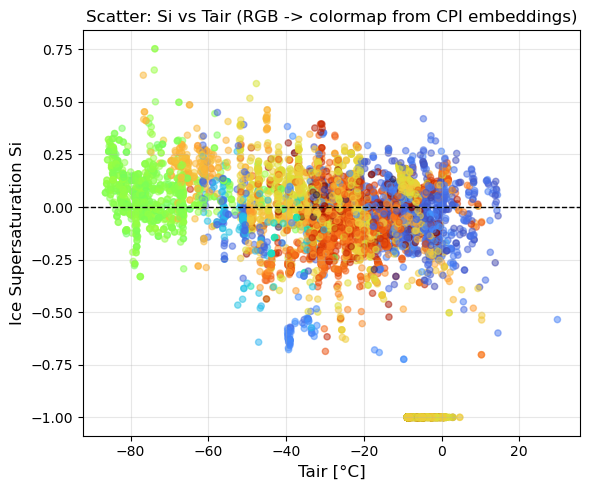

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import colorsys
import polars as pl

# -----------------------------
# Step 0: Sample points for plotting (optional)
# -----------------------------
# Convert Polars to Pandas for easy plotting
# n_samples = len(df_merged)
n_samples=10_000
df_plot = df_merged.select(["Tair_C", "Si", "r", "g", "b"]).sample(n=n_samples, seed=42).to_pandas()

# -----------------------------
# Step 1: Convert RGB 0-255 -> 0-1 floats
# -----------------------------
rgb_vals = df_plot[["r", "g", "b"]].values / 255.0

# -----------------------------
# Step 2: Convert RGB -> HSV -> Hue
# -----------------------------
hsv = np.array([colorsys.rgb_to_hsv(r, g, b) for r, g, b in rgb_vals])
hue = hsv[:, 0]  # 0..1

# -----------------------------
# Step 3: Map hue to matplotlib colormap
# -----------------------------
cmap = plt.cm.turbo
colors = cmap(hue)

# -----------------------------
# Step 4: Scatter plot
# -----------------------------
plt.figure(figsize=(6, 5))
plt.scatter(
    df_plot["Tair_C"],
    df_plot["Si"],
    c=colors,
    s=20,
    alpha=0.5
)

# Horizontal line at Si=0
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.xlabel("Tair [°C]", fontsize=12)
plt.ylabel("Ice Supersaturation Si", fontsize=12)
plt.title("Scatter: Si vs Tair (RGB -> colormap from CPI embeddings)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

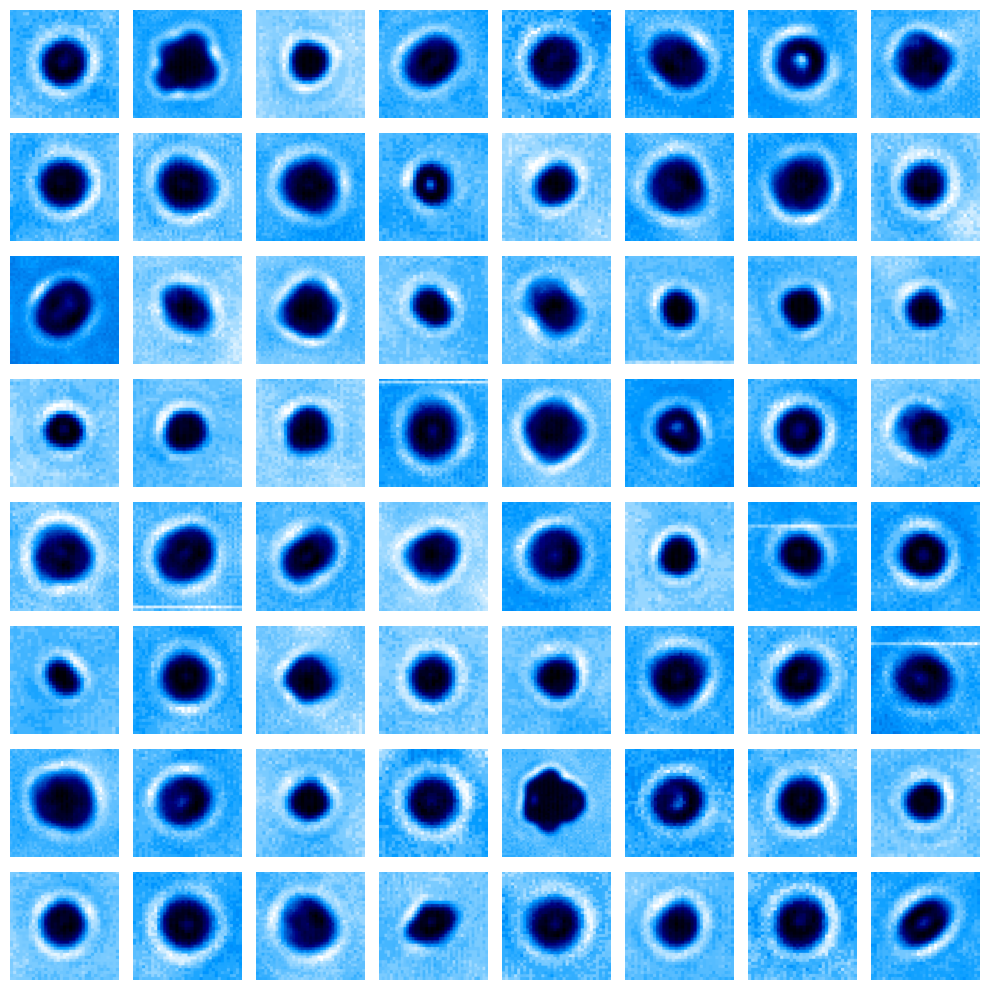

In [67]:
# Show samples of CPI images within user-defined extent.
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------
# Step 0: Define selection criteria
# -----------------------------
cpi_base_dir = '/home/vanessa/hulk/cocpit/cpi_data/campaigns'
tmin, tmax = -90, -80       # Tair extent
smin, smax = 0, 0.25    # Si extent
n_samples = 64            # number of images to plot

# -----------------------------
# Step 1: Filter df_merged based on Tair and Si
# -----------------------------
df_filtered = df_merged.filter(
    (pl.col("Tair_C") >= tmin) & (pl.col("Tair_C") <= tmax) &
    (pl.col("Si") >= smin) & (pl.col("Si") <= smax)
)

# -----------------------------
# Step 2: Sample n_samples images
# -----------------------------
n_available = df_filtered.height
n_take = min(n_samples, n_available)
df_sampled = df_filtered.sample(n=n_take, seed=42)

# -----------------------------
# Step 3: Map campaigns to directory names
# -----------------------------
campaign_dir_map = {
    "CRYSTAL-FACE-NASA": "CRYSTAL_FACE_NASA",
    "CRYSTAL-FACE-UND": "CRYSTAL_FACE_UND",
    # other campaigns map directly
    "ARM": "ARM",
    "MIDCIX": "MIDCIX",
    "MC3E": "MC3E",
    "OLYMPEX": "OLYMPEX"
}

# -----------------------------
# Step 4: Prepare image paths
# -----------------------------
image_paths = []
for row in df_sampled.to_dicts():
    campaign_dir = campaign_dir_map.get(row["campaign"], row["campaign"])
    img_path = os.path.join(
        cpi_base_dir,
        campaign_dir,
        "single_imgs_v1.4.0",
        os.path.basename(row["filename"])
    )
    image_paths.append(img_path)

# -----------------------------
# Step 5: Load images
# -----------------------------
images = []
for path in image_paths:
    if os.path.exists(path):
        img = Image.open(path).convert("RGB")
        images.append(img)
    else:
        print(f"Warning: {path} does not exist")
        images.append(Image.new("RGB", (64, 64), (0, 0, 0)))  # black placeholder

# -----------------------------
# Step 6: Plot images in a grid
# -----------------------------
grid_size = int(np.ceil(np.sqrt(n_take)))  # make square-ish grid
fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    if i < n_take:
        ax.imshow(images[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TO-DO

# Bin relative percent of classes by temp/Si (use supervised labels)

# Ask CPI people spheres. Paul Lawson? Greg M.? 

# expand on similarity metrics as function of thermodynamic variables
